In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('tested.csv')
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


(None,
        PassengerId    Survived      Pclass         Age       SibSp  \
 count   418.000000  418.000000  418.000000  332.000000  418.000000   
 mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
 std     120.810458    0.481622    0.841838   14.181209    0.896760   
 min     892.000000    0.000000    1.000000    0.170000    0.000000   
 25%     996.250000    0.000000    1.000000   21.000000    0.000000   
 50%    1100.500000    0.000000    3.000000   27.000000    0.000000   
 75%    1204.750000    1.000000    3.000000   39.000000    1.000000   
 max    1309.000000    1.000000    3.000000   76.000000    8.000000   
 
             Parch        Fare  
 count  418.000000  418.000000  
 mean     0.392344   35.560018  
 std      0.981429   55.857385  
 min      0.000000    0.000000  
 25%      0.000000    7.895800  
 50%      0.000000   14.454200  
 75%      0.000000   31.471875  
 max      9.000000  512.329200  )

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

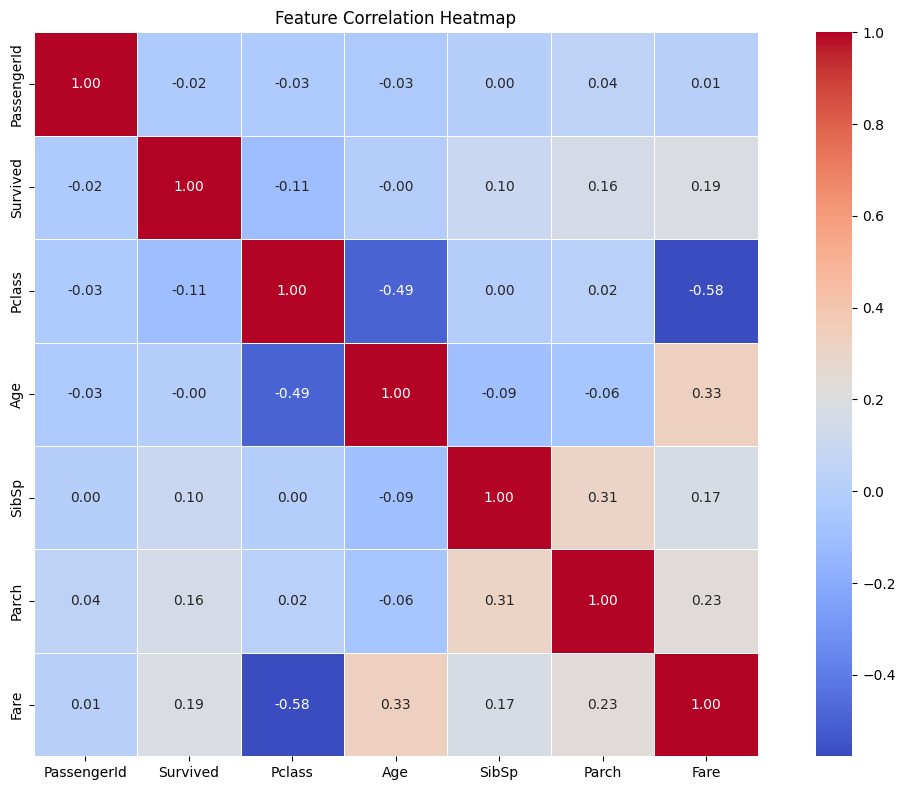

In [12]:
df_clean = df.drop(columns=['Name','Sex','Cabin', 'Embarked','Ticket'])
corr_matrix = df_clean.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ***UNIVARIATE ANALYSIS***

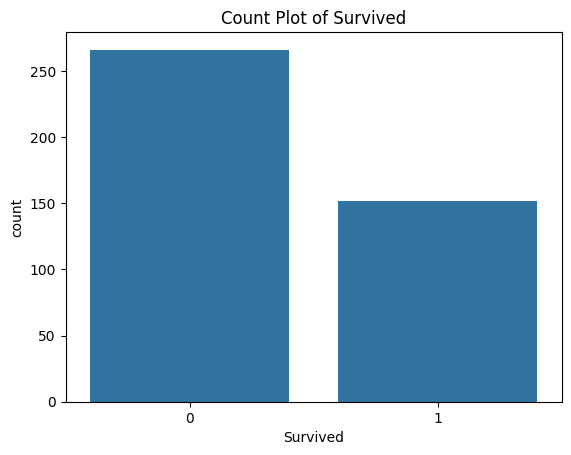

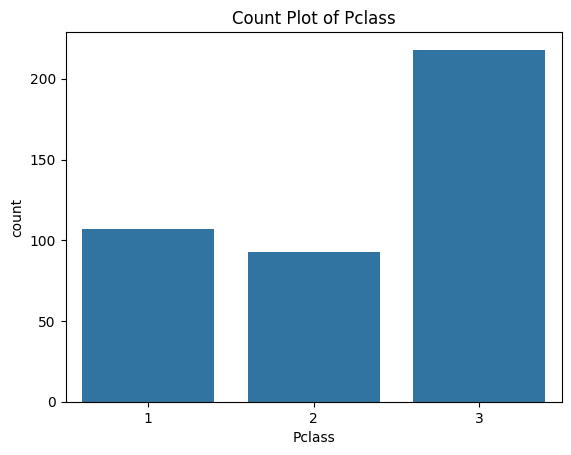

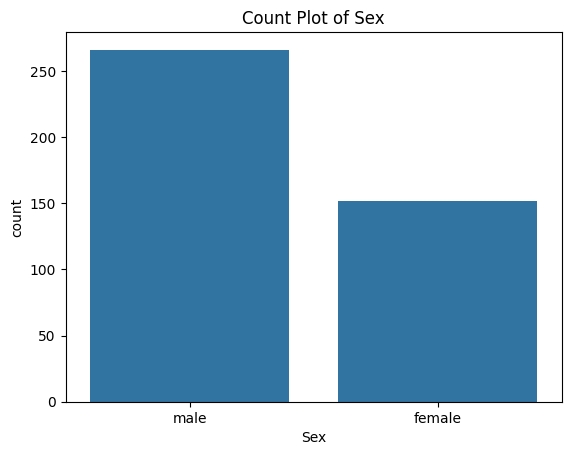

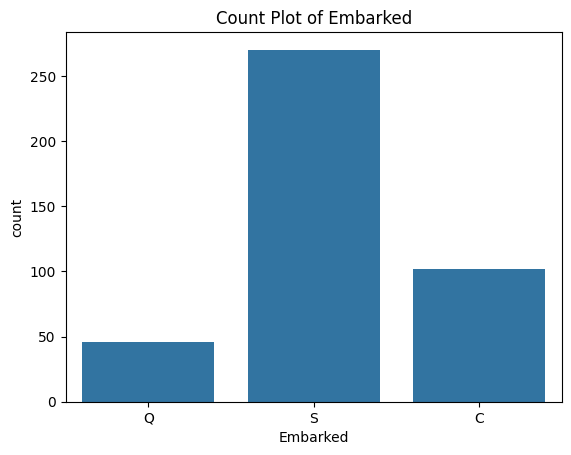

In [13]:
# Univariate Analysis: Categorical
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.show()

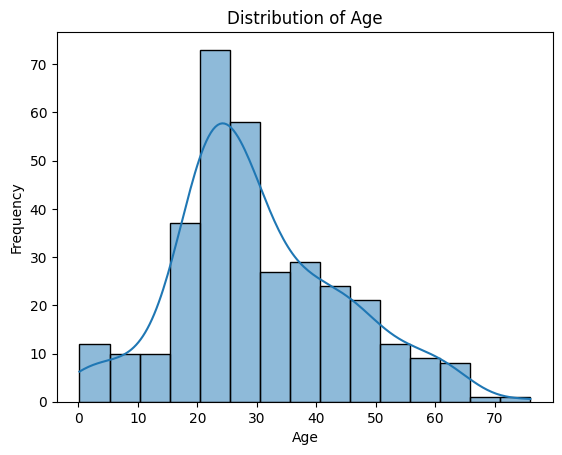

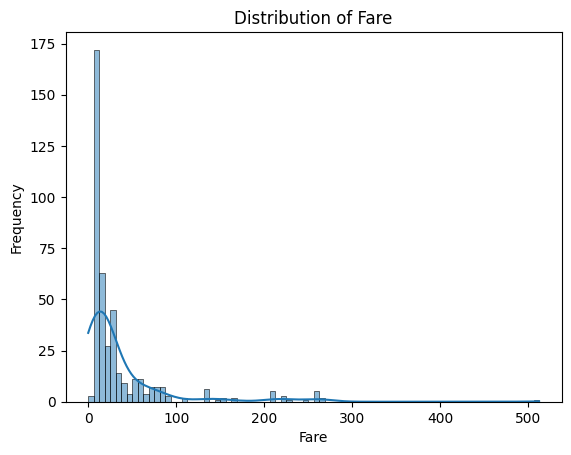

In [14]:
# Univariate Analysis: Numerical
numerical_cols = ['Age', 'Fare']
for col in numerical_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

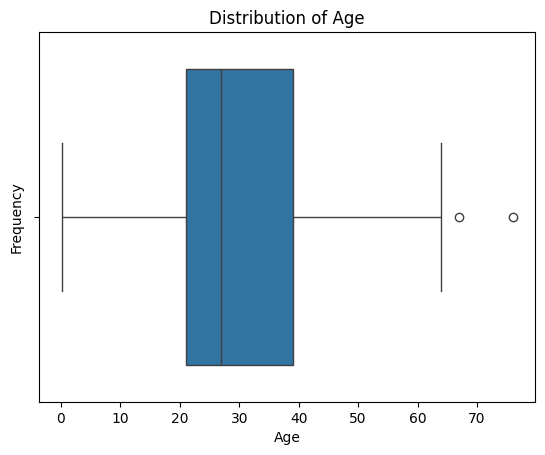

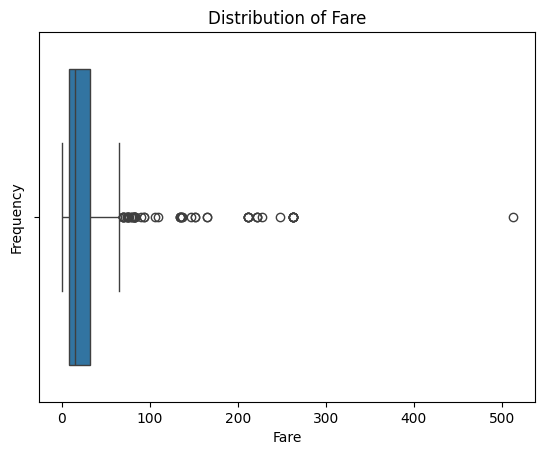

In [15]:
# Univariate Analysis: Numerical
numerical_cols = ['Age', 'Fare']
for col in numerical_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# ***BIVARIATE ANALYSIS***

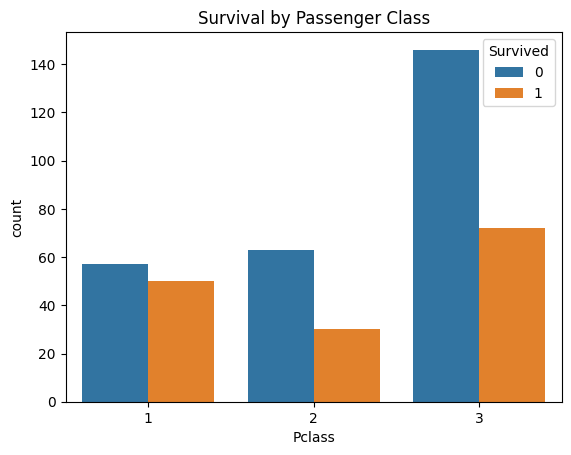

In [16]:
# Bivariate Analysis: Categorical vs Categorical
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.show()

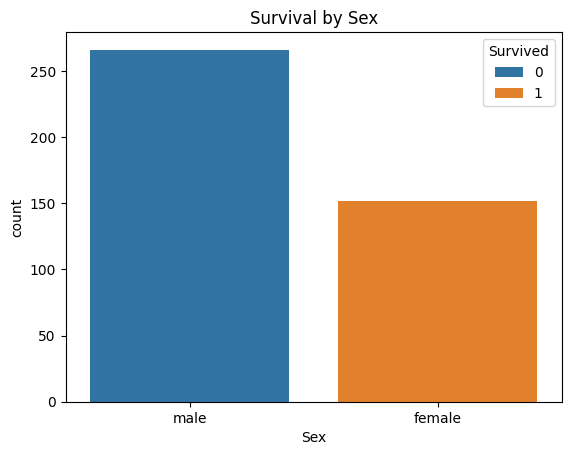

In [17]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.show()

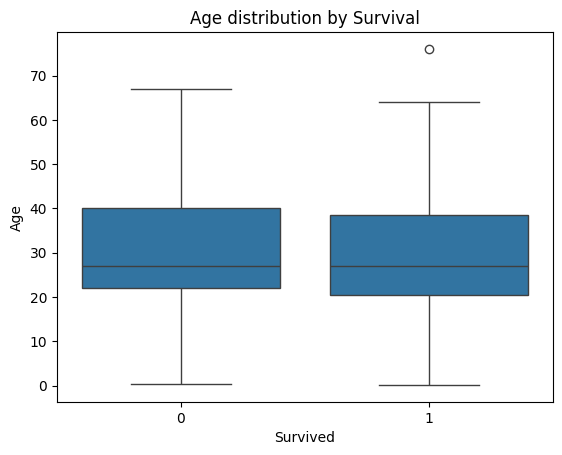

In [18]:
# Bivariate: Numerical vs Categorical (Box plots)
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age distribution by Survival')
plt.show()

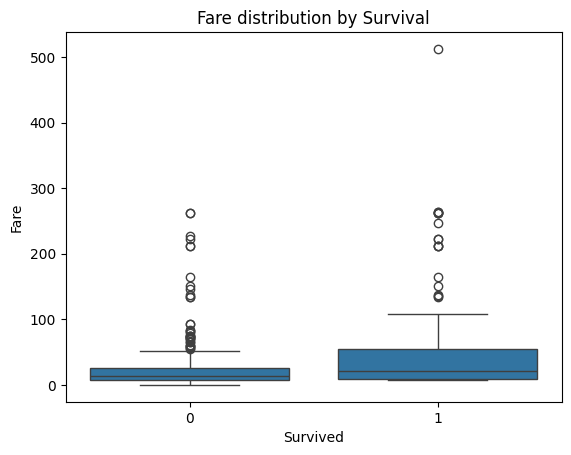

In [19]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare distribution by Survival')
plt.show()

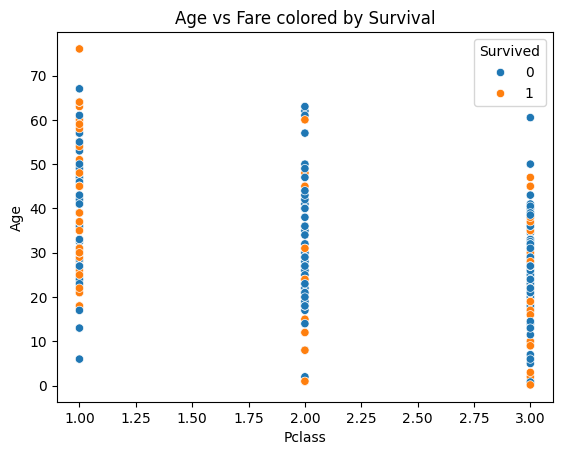

In [8]:
# Bivariate: Scatter (Numerical vs Numerical)
sns.scatterplot(data=df, y='Age', x='Pclass', hue='Survived')
plt.title('Age vs Fare colored by Survival')
plt.show()

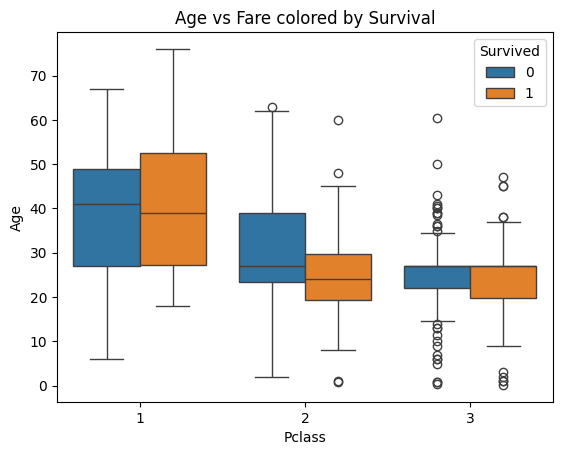

In [9]:
# Bivariate: Scatter (Numerical vs Numerical)
sns.boxplot(data=df, y='Age', x='Pclass', hue='Survived')
plt.title('Age vs Fare colored by Survival')
plt.show()

# ***MULTI VARIATE ANALYSIS***

In [6]:
# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin'], inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

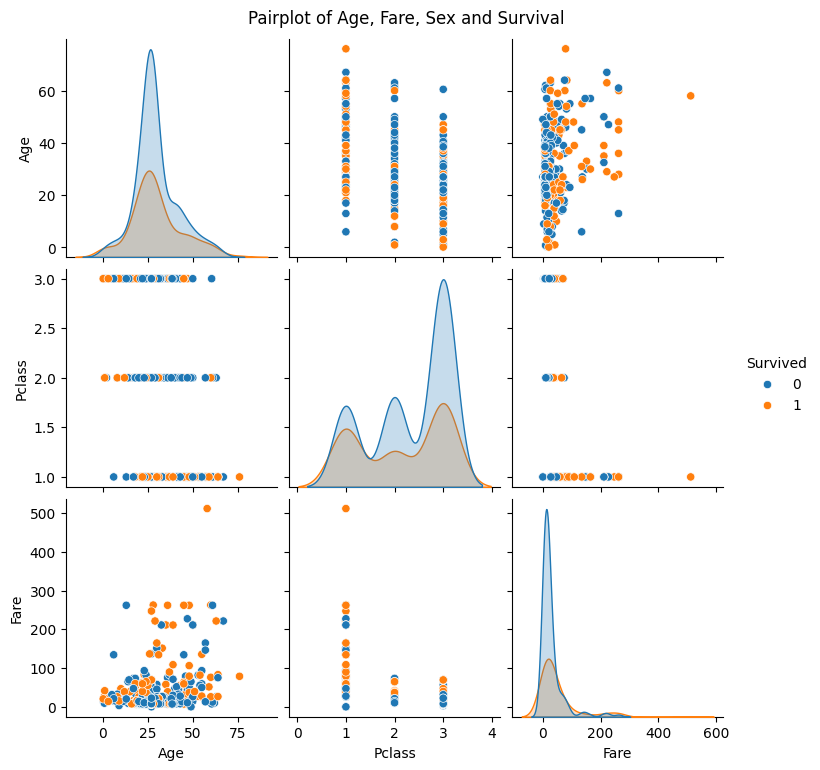

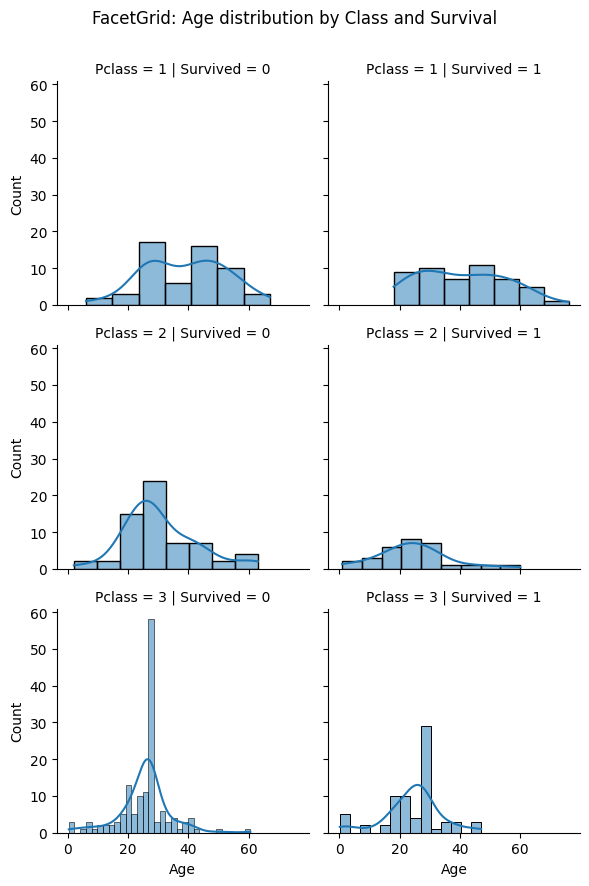

In [12]:
# Multivariate: Pair Plot (requires encoded data)
sns.pairplot(df_encoded[['Age', 'Pclass', 'Survived', 'Fare']], hue='Survived')
plt.suptitle('Pairplot of Age, Fare, Sex and Survival', y=1.02)
plt.show()


# Multivariate: FacetGrid
g = sns.FacetGrid(df, row='Pclass', col='Survived')
g.map(sns.histplot, 'Age', kde=True)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('FacetGrid: Age distribution by Class and Survival')
plt.show()

<Axes: xlabel='Survived', ylabel='Pclass-AgeGroup'>

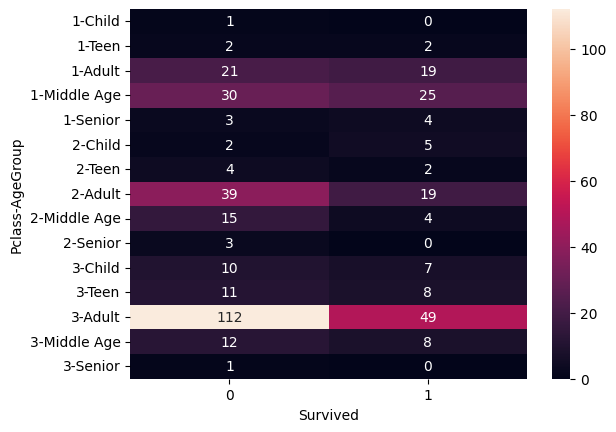

In [10]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])
sns.heatmap(pd.crosstab([df['Pclass'], df['AgeGroup']], df['Survived']), annot=True, fmt='d')

Mean Age: 29.599282296650717
Median Age: 27.0
Mode Age: 27.0
Standard Deviation Age: 12.703769846333287


Mean Fare: 35.56001818181818
Median Fare: 14.4542
Mode Fare: 7.75
Standard Deviation Fare: 55.85738489391629


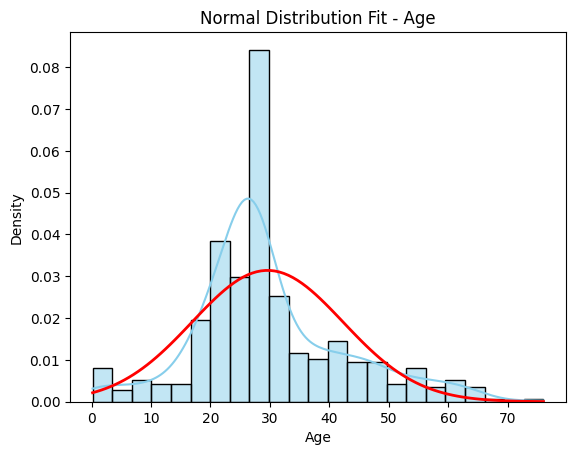

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer

# Load your dataset
df = pd.read_csv("tested.csv")

# ----------------- Missing Values -----------------
imputer = SimpleImputer(strategy='median')
df['Age'] = imputer.fit_transform(df[['Age']])
df.drop(columns=['Cabin'], inplace=True)  # Drop Cabin due to too many missing values

# ----------------- Descriptive Statistics -----------------
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())
print("Mode Age:", df['Age'].mode()[0])
print("Standard Deviation Age:", df['Age'].std())
print('\n')
print("Mean Fare:", df['Fare'].mean())
print("Median Fare:", df['Fare'].median())
print("Mode Fare:", df['Fare'].mode()[0])
print("Standard Deviation Fare:", df['Fare'].std())

# ----------------- Normal Distribution Plot -----------------
sns.histplot(df['Age'], kde=True, stat='density', color='skyblue')
x = np.linspace(df['Age'].min(), df['Age'].max(), 100)
p = stats.norm.pdf(x, df['Age'].mean(), df['Age'].std())
plt.plot(x, p, 'r', linewidth=2)
plt.title("Normal Distribution Fit - Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

In [24]:
# ----------------- Hypothesis Testing -----------------
# T-test: Age vs Survived
t_stat, p_val = stats.ttest_ind(df[df['Survived'] == 1]['Age'], df[df['Survived'] == 0]['Age'])
print("T-Test - Age by Survival: t-stat =", t_stat, ", p-value =", p_val)

# Chi-Square: Sex vs Survived
contingency_table = pd.crosstab(df['Sex'], df['Survived'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-Square Test - Sex vs Survived: chi2 =", chi2, ", p-value =", p_chi)

# ANOVA: Fare vs Survived
anova_stat, anova_p = stats.f_oneway(
    df[df['Survived'] == 0]['Fare'],
    df[df['Survived'] == 1]['Fare']
)
print("ANOVA - Fare by Survival: F =", anova_stat, ", p-value =", anova_p)

T-Test - Age by Survival: t-stat = 0.16387781652103198 , p-value = 0.869906919527237
Chi-Square Test - Sex vs Survived: chi2 = 413.6897405343716 , p-value = 5.767311139789629e-92
ANOVA - Fare by Survival: F = 15.9628402525373 , p-value = 7.639678413339524e-05


In [25]:
# ----------------- Feature Scaling -----------------
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df_encoded[['Age_minmax', 'Fare_minmax']] = minmax_scaler.fit_transform(df_encoded[['Age', 'Fare']])
df_encoded[['Age_std', 'Fare_std']] = standard_scaler.fit_transform(df_encoded[['Age', 'Fare']])

# View first few rows of scaled data
print(df_encoded[['Age_minmax', 'Fare_minmax', 'Age_std', 'Fare_std']].head())

   Age_minmax  Fare_minmax   Age_std  Fare_std
0    0.452723     0.015282  0.386231 -0.497052
1    0.617566     0.013663  1.371370 -0.511915
2    0.815377     0.018909  2.553537 -0.463744
3    0.353818     0.016908 -0.204852 -0.482116
4    0.287881     0.023984 -0.598908 -0.417141


Poisson Probabilities (Pclass ~ mu=2.2655502392344498): [0.23510276 0.26631856 0.20111936]


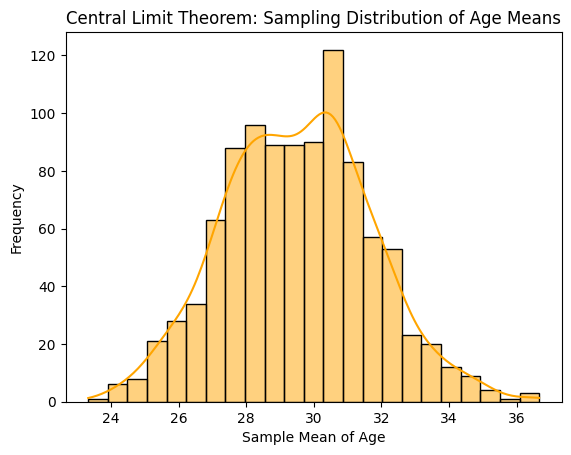

In [27]:
# ----------------- Poisson Distribution Example -----------------
mu = df['Pclass'].mean()
poisson_probs = stats.poisson.pmf(k=[1, 2, 3], mu=mu)
print("Poisson Probabilities (Pclass ~ mu={}):".format(mu), poisson_probs)

# ----------------- Central Limit Theorem (CLT) -----------------
sample_means = [df['Age'].sample(30).mean() for _ in range(1000)]
sns.histplot(sample_means, kde=True, color='orange')
plt.title("Central Limit Theorem: Sampling Distribution of Age Means")
plt.xlabel("Sample Mean of Age")
plt.ylabel("Frequency")
plt.show()